# Итоговый анализ NL2SQL

Ноутбук содержит итоговый анализ экспериментальных результатов в задаче `NL2SQL`. Цель анализа — проверить, может ли компактная специализированная модель обеспечивать качество генерации SQL, сопоставимое с качеством крупной универсальной языковой модели, при ином вычислительном профиле.

Основная часть анализа опирается на сопоставимые результаты режима `EA`. Главная метрика качества — `Execution Accuracy`: доля задач, в которых первый выбранный SQL-запрос даёт корректный результат при выполнении. Интегральная метрика `Eff` используется для описания вычислительного профиля, а `Pass@K` рассматривается отдельно как характеристика режима многократной генерации.


## Содержание

1. Данные и воспроизводимость
2. Исследовательская постановка
3. Состав сравниваемых моделей
4. Распределение EA на уровне агрегированных результатов
5. Проверка гипотезы и оценка достижимого уровня качества
6. Парные сравнения на общем наборе задач
7. Структурные различия между Spider и BIRD
8. Интегральная метрика вычислительной эффективности и ее компоненты
9. Экспертная оценка успешных SQL-запросов
10. Ограничения исследования
11. Приложение A: Дополнительные результаты EA
12. Приложение B: Pass@K
13. Приложение C: Результаты локального синтетического бенчмарка
14. Итоговые выводы


## 1. Данные и воспроизводимость

В разделе загружаются итоговые артефакты экспериментов и фиксируется источник данных, на котором основан анализ. Ноутбук работает поверх уже рассчитанных результатов из `results/nl2sql` и воспроизводит итоговые таблицы и графики без повторного запуска инференса.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from nl2sql.notebooks.analysis_utils import (
    RESULTS_DIR,
    build_completeness_audit,
    compute_pairwise_ea_deltas,
    compute_sample_outcomes,
    filter_appendix_rows,
    filter_main_report_rows,
    get_expected_sample_counts,
    get_figures_dir,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.float_format = '{:.4f}'.format

RUN_LABEL = 'ea'
PASS_K_LABEL = 'pass_k'
EXPECTED_COUNTS = get_expected_sample_counts(RUN_LABEL)
FIGURES_DIR = get_figures_dir('final')
palette = {'m1': '#1b9e77', 'm2': '#d95f02'}


## 2. Исследовательская постановка

В работе проверяется следующая гипотеза:

> специализированная компактная модель способна обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели, при ином профиле вычислительных затрат.

Основной метрикой качества является `EA`, поскольку она показывает долю задач, в которых первый выбранный SQL-запрос эквивалентен эталону по результату выполнения. Вычислительная эффективность рассматривается отдельно через интегральную метрику `Eff`, а `Pass@K` используется как вспомогательная характеристика режима многократной генерации. Эти метрики отвечают на разные исследовательские вопросы и не подменяют друг друга.


## 3. Состав сравниваемых моделей

Перед сравнительным анализом фиксируется состав сопоставимого корпуса результатов. В основную часть исследования включаются только модели, для которых доступны сопоставимые значения `EA` на бенчмарках `Spider` и `BIRD`. Это делает межмодельное сравнение корректным.

Итоговый вывод строится по единому набору задач, на котором все сравниваемые модели наблюдаются в одинаковых условиях.


In [2]:
reset_analysis_caches()
ea_samples_df, ea_generations_df = load_records(RUN_LABEL)
ea_summary_df = cast(Any, load_summary_metrics(RUN_LABEL).copy())
ea_outcomes_df = cast(Any, compute_sample_outcomes(RUN_LABEL).copy())
ea_audit_df = cast(Any, build_completeness_audit(RUN_LABEL, summary_df=ea_summary_df, expected_counts=EXPECTED_COUNTS))
main_ea_df = cast(Any, filter_main_report_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
appendix_ea_df = cast(Any, filter_appendix_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
main_model_names = sorted(main_ea_df['model_name'].unique().tolist())
appendix_model_names = sorted(appendix_ea_df['model_name'].unique().tolist())

display(Markdown(f'**Источник данных и артефактов:** `{RESULTS_DIR}`'))

comparison_view = ea_audit_df[[
    'model_display_name',
    'model_family',
    'spider_n_samples',
    'bird_n_samples',
    'is_complete',
]].copy()
comparison_view = comparison_view[comparison_view['model_display_name'].isin(set(main_ea_df['model_display_name']))].rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'spider_n_samples': 'Число задач Spider',
    'bird_n_samples': 'Число задач BIRD',
    'is_complete': 'Включена в сравнение',
})
display(Markdown('**Таблица 1. Состав моделей, включенных в основное сравнение**'))
display(comparison_view.sort_values(['Класс модели', 'Модель']).reset_index(drop=True))
display(Markdown(f'**Модели, включенные в основное сравнение:** {sorted(main_ea_df["model_display_name"].unique().tolist())}'))
if appendix_model_names:
    display(Markdown('Дополнительные результаты приведены в приложении A.'))


**Источник данных и артефактов:** `/home/count/code/vkr/results/nl2sql`

**Таблица 1. Состав моделей, включенных в основное сравнение**

,Модель,Класс модели,Число задач Spider,Число задач BIRD,Включена в сравнение
0,ChatGPT 5.2,m1,1034,1534,True
1,DeepSeek V3.2,m1,1034,1534,True
2,Arctic-Text2SQL-R1-7B,m2,1034,1534,True
3,Defog-Llama3-SQLCoder-8B q4_0,m2,1034,1534,True
4,Hrida-T2SQL q8_0,m2,1034,1534,True


**Модели, включенные в основное сравнение:** ['Arctic-Text2SQL-R1-7B', 'ChatGPT 5.2', 'DeepSeek V3.2', 'Defog-Llama3-SQLCoder-8B q4_0', 'Hrida-T2SQL q8_0']

Дополнительные результаты приведены в приложении A.

## 4. Распределение `EA` на уровне агрегированных результатов

Для каждой модели рассматривается не только среднее значение `EA`, но и bootstrap-оценка распределения агрегированной метрики через квантили `q05`, `q50` и `q95`. Такой способ представления заменяет одну точечную оценку интервалом возможных значений и делает последующее сравнение более устойчивым.


In [3]:
ea_view_cols = [
    'model_display_name', 'model_family', 'benchmark', 'n_samples',
    'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q50', 'execution_accuracy_q95',
]
ea_view_df = main_ea_df[ea_view_cols].sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
ea_view_display = ea_view_df.rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'benchmark': 'Бенчмарк',
    'n_samples': 'Число задач',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q50': 'EA q50',
    'execution_accuracy_q95': 'EA q95',
})
display(Markdown('**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**'))
display(ea_view_display.round(4))


**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**

,Модель,Класс модели,Бенчмарк,Число задач,EA,EA q05,EA q50,EA q95
0,ChatGPT 5.2,m1,bird,1534,0.3657,0.3468,0.3657,0.3853
1,DeepSeek V3.2,m1,bird,1534,0.3227,0.3031,0.3227,0.3422
2,Arctic-Text2SQL-R1-7B,m2,bird,1534,0.5385,0.5150,0.5388,0.5593
3,Defog-Llama3-SQLCoder-8B q4_0,m2,bird,1534,0.2634,0.2458,0.2634,0.2823
4,Hrida-T2SQL q8_0,m2,bird,1534,0.1551,0.1402,0.1551,0.1701
5,ChatGPT 5.2,m1,spider,1034,0.7427,0.7195,0.7427,0.7650
6,DeepSeek V3.2,m1,spider,1034,0.7369,0.7147,0.7369,0.7592
7,Arctic-Text2SQL-R1-7B,m2,spider,1034,0.7718,0.7495,0.7718,0.7921
8,Defog-Llama3-SQLCoder-8B q4_0,m2,spider,1034,0.5629,0.5387,0.5629,0.5880
9,Hrida-T2SQL q8_0,m2,spider,1034,0.4913,0.4652,0.4913,0.5155


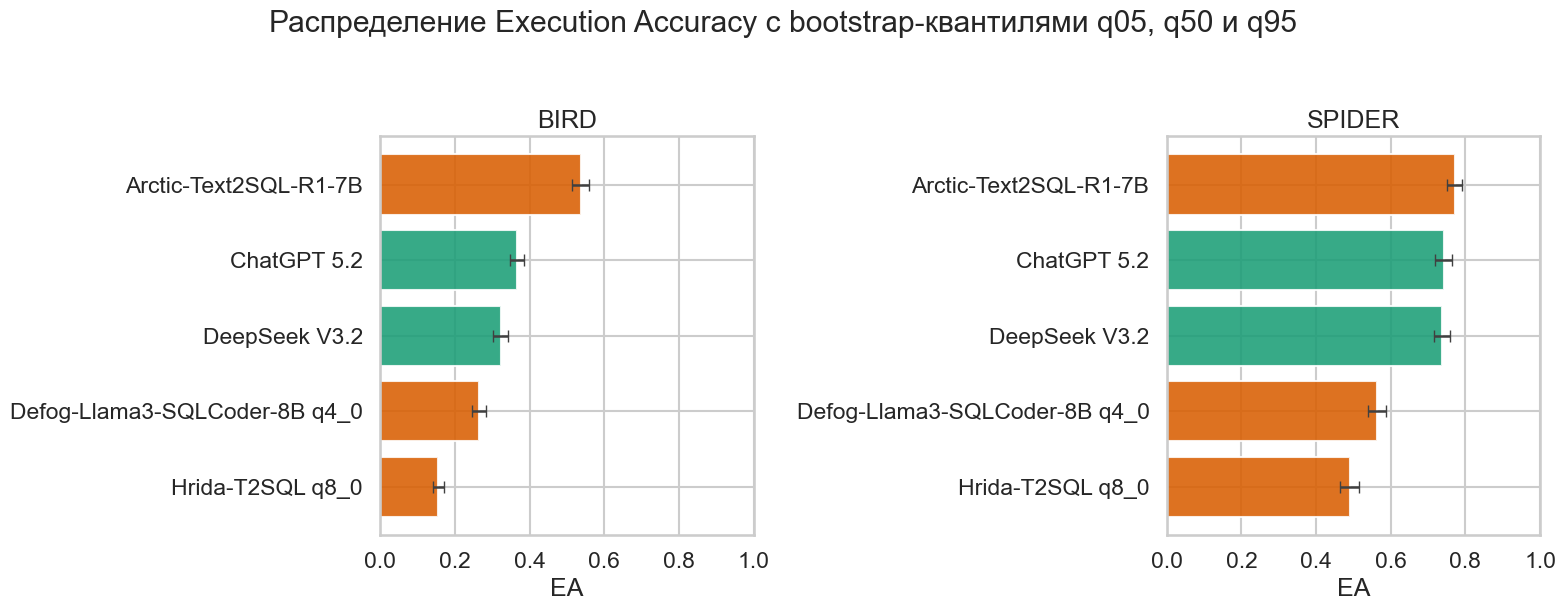

In [4]:
benchmarks = list(ea_view_df['benchmark'].dropna().unique())
fig, axes = plt.subplots(1, len(benchmarks), figsize=(8 * max(len(benchmarks), 1), 6), sharex=False)
if len(benchmarks) == 1:
    axes = [axes]
for ax, benchmark in zip(axes, benchmarks):
    subset = ea_view_df[ea_view_df['benchmark'] == benchmark].sort_values('execution_accuracy')
    y = np.arange(len(subset))
    x = subset['execution_accuracy'].to_numpy()
    lower = x - subset['execution_accuracy_q05'].to_numpy()
    upper = subset['execution_accuracy_q95'].to_numpy() - x
    colors = subset['model_family'].map(palette).tolist()
    ax.barh(y, x, color=colors, alpha=0.88)
    ax.errorbar(x, y, xerr=np.vstack([lower, upper]), fmt='none', ecolor='0.25', capsize=4, linewidth=1.8)
    ax.set_yticks(y)
    ax.set_yticklabels(subset['model_display_name'])
    ax.set_xlim(0, 1)
    ax.set_title(benchmark.upper())
    ax.set_xlabel('EA')
fig.suptitle('Распределение Execution Accuracy с bootstrap-квантилями q05, q50 и q95', y=1.03)
fig.tight_layout()
plt.show()


Визуализация показывает, что различия между моделями воспроизводятся на обоих наборах данных, но их масштаб зависит от сложности набора. На Spider значения `EA` в целом выше, тогда как на BIRD интервалы смещены вниз для всех моделей. Поэтому вывод о сопоставимости классов моделей нельзя формулировать без явного указания набора данных.


## 5. Проверка гипотезы и оценка достижимого уровня качества

В этом разделе результаты `EA` интерпретируются в логике проверяемой гипотезы: оценивается, можно ли считать качество специализированных компактных моделей сопоставимым с качеством больших универсальных моделей на Spider и BIRD, и при каких условиях это утверждение сохраняется.

Сначала сравниваются лучшие представители классов `M1` и `M2`, после чего отдельно проверяется, достигают ли они уровня качества, близкого к диапазону `EA = 0.8-0.9`.


In [5]:
best_by_family_df = cast(Any, (
    main_ea_df.sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
    .groupby(['benchmark', 'model_family'], as_index=False)
    .first()
))
best_by_family_df['delta_to_other_family'] = np.nan
for benchmark in sorted(best_by_family_df['benchmark'].unique()):
    subset = best_by_family_df[best_by_family_df['benchmark'] == benchmark].set_index('model_family')
    if {'m1', 'm2'}.issubset(subset.index):
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm2'), 'delta_to_other_family'] = subset.loc['m2', 'execution_accuracy'] - subset.loc['m1', 'execution_accuracy']
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm1'), 'delta_to_other_family'] = subset.loc['m1', 'execution_accuracy'] - subset.loc['m2', 'execution_accuracy']

best_by_family_view = best_by_family_df[['benchmark', 'model_family', 'model_display_name', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q95', 'delta_to_other_family']].copy()
best_by_family_view = best_by_family_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'model_family': 'Класс модели',
    'model_display_name': 'Лучшая модель в классе',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q95': 'EA q95',
    'delta_to_other_family': 'Разность EA с другим классом',
})
display(Markdown('**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**'))
display(best_by_family_view.round(4))


**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**

,Бенчмарк,Класс модели,Лучшая модель в классе,EA,EA q05,EA q95,Разность EA с другим классом
0,bird,m1,ChatGPT 5.2,0.3657,0.3468,0.3853,-0.1728
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5385,0.5150,0.5593,0.1728
2,spider,m1,ChatGPT 5.2,0.7427,0.7195,0.7650,-0.0290
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,0.7495,0.7921,0.0290


In [6]:
target_rows = []
for benchmark, subset in best_by_family_df.groupby('benchmark'):
    for family in ['m1', 'm2']:
        row = subset[subset['model_family'] == family].iloc[0]
        target_rows.append({
            'Бенчмарк': benchmark,
            'Класс модели': family,
            'Лучшая модель': row['model_display_name'],
            'EA': row['execution_accuracy'],
            'Попадание в диапазон 0.8-0.9': bool(0.8 <= row['execution_accuracy'] <= 0.9),
        })
target_df = pd.DataFrame(target_rows)
display(Markdown('**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**'))
display(target_df)


**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**

,Бенчмарк,Класс модели,Лучшая модель,EA,Попадание в диапазон 0.8-0.9
0,bird,m1,ChatGPT 5.2,0.3657,False
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5385,False
2,spider,m1,ChatGPT 5.2,0.7427,False
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,False


Сопоставление лучших представителей классов `M1` и `M2` показывает, что вопрос о сопоставимости качества нельзя решать без учёта конкретного набора данных. На Spider различие между сильнейшими представителями классов невелико, тогда как на BIRD преимущество специализированной модели выражено заметно сильнее. Проверка диапазона `EA = 0.8-0.9` дополнительно показывает, что ни один из рассматриваемых кандидатов не достигает этого уровня на полном наборе задач.


## 6. Парные сравнения на общем наборе задач

Чтобы не ограничиваться сравнением агрегированных средних, далее рассчитывается `ΔEA` на одних и тех же задачах для каждой пары моделей. Такой анализ позволяет оценить не только величину различия, но и его устойчивость на общем наборе наблюдений.


In [7]:
pairwise_df = cast(Any, compute_pairwise_ea_deltas(RUN_LABEL, outcomes_df=ea_outcomes_df, allowed_models=main_model_names))
pairwise_view = pairwise_df[['benchmark', 'comparison', 'matched_samples', 'left_ea', 'right_ea', 'delta_ea', 'delta_ea_q05', 'delta_ea_q50', 'delta_ea_q95']].copy()
pairwise_view = pairwise_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'comparison': 'Сравнение моделей',
    'matched_samples': 'Число общих задач',
    'left_ea': 'EA модели A',
    'right_ea': 'EA модели B',
    'delta_ea': 'ΔEA',
    'delta_ea_q05': 'ΔEA q05',
    'delta_ea_q50': 'ΔEA q50',
    'delta_ea_q95': 'ΔEA q95',
})
pairwise_view['Сравнение моделей'] = pairwise_view['Сравнение моделей'].str.replace(' vs ', ' против ', regex=False)
display(Markdown('**Таблица 5. Парные различия `EA` на общем наборе задач**'))
display(pairwise_view.round(4))


**Таблица 5. Парные различия `EA` на общем наборе задач**

,Бенчмарк,Сравнение моделей,Число общих задач,EA модели A,EA модели B,ΔEA,ΔEA q05,ΔEA q50,ΔEA q95
0,bird,Arctic-Text2SQL-R1-7B против Hrida-T2SQL q8_0,1534,0.5385,0.1551,0.3833,0.3618,0.3827,0.4042
1,bird,Arctic-Text2SQL-R1-7B против Defog-Llama3-SQLC...,1534,0.5385,0.2634,0.2751,0.2516,0.2751,0.2979
2,bird,Arctic-Text2SQL-R1-7B против DeepSeek V3.2,1534,0.5385,0.3227,0.2158,0.1930,0.2145,0.2373
3,bird,ChatGPT 5.2 против Hrida-T2SQL q8_0,1534,0.3657,0.1551,0.2106,0.1890,0.2112,0.2353
4,bird,Arctic-Text2SQL-R1-7B против ChatGPT 5.2,1534,0.5385,0.3657,0.1728,0.1493,0.1721,0.1956
5,bird,DeepSeek V3.2 против Hrida-T2SQL q8_0,1534,0.3227,0.1551,0.1675,0.1454,0.1682,0.1910
6,bird,Defog-Llama3-SQLCoder-8B q4_0 против Hrida-T2S...,1534,0.2634,0.1551,0.1082,0.0893,0.1082,0.1271
7,bird,ChatGPT 5.2 против Defog-Llama3-SQLCoder-8B q4_0,1534,0.3657,0.2634,0.1023,0.0808,0.1030,0.1258
8,bird,DeepSeek V3.2 против Defog-Llama3-SQLCoder-8B ...,1534,0.3227,0.2634,0.0593,0.0384,0.0593,0.0854
9,bird,ChatGPT 5.2 против DeepSeek V3.2,1534,0.3657,0.3227,0.0430,0.0274,0.0430,0.0600


Парные сравнения уточняют вывод по средним значениям: различия между моделями возникают не из-за нескольких отдельных выбросов, а сохраняются на общем наборе задач. Это особенно важно для `BIRD`, где преимущество сильнейшей специализированной модели относительно лучших `M1` выглядит устойчивым, а не случайным.


## 7. Структурные различия между Spider и BIRD

Оценивать сопоставимость качества только по Spider недостаточно. Spider и BIRD различаются не только формально, но и содержательно: на более реалистичном и сложном наборе поведение моделей меняется, и именно это задаёт границы применимости итогового вывода.

Дальнейший анализ разделён на два независимых смысловых блока. Сначала рассматривается стратификация `Execution Accuracy` по сложности и длине вопроса: этот график отвечает на вопрос, в каких частях набора качество падает сильнее. Затем отдельно рассматривается структура исходов выполнения SQL: этот график показывает, чем именно заканчиваются попытки генерации — корректным результатом, ошибкой выполнения, пустым SQL или исполнимым, но семантически неверным результатом.


In [8]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
OUTCOME_LABELS = {
    'correct': 'корректный результат',
    'execution_error': 'ошибка выполнения',
    'empty_sql': 'пустой SQL',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}

main_outcomes_df = cast(Any, ea_outcomes_df[ea_outcomes_df['model_name'].isin(main_model_names)].copy())
main_outcomes_df['benchmark_ru'] = main_outcomes_df['benchmark'].map(BENCHMARK_LABELS).fillna(main_outcomes_df['benchmark'])
main_outcomes_df['difficulty_ru'] = main_outcomes_df['difficulty'].map(DIFFICULTY_LABELS).fillna(main_outcomes_df['difficulty'])

def categorize_error(row: pd.Series) -> str:
    if bool(row['first_hit']):
        return 'correct'
    if bool(row.get('empty_sql', False)):
        return 'empty_sql'
    if not bool(row.get('first_pred_success', False)):
        return 'execution_error'
    return 'wrong_result'

main_outcomes_df['error_type'] = main_outcomes_df.apply(categorize_error, axis=1)
main_outcomes_df['outcome_ru'] = main_outcomes_df['error_type'].map(OUTCOME_LABELS).fillna(main_outcomes_df['error_type'])

difficulty_df = (
    main_outcomes_df.dropna(subset=['difficulty_ru'])
    .groupby(['benchmark', 'benchmark_ru', 'difficulty_ru'], as_index=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
main_outcomes_df['question_len_bucket'] = pd.qcut(main_outcomes_df['question_len'], q=4, duplicates='drop')
question_len_df = (
    main_outcomes_df.groupby(['benchmark', 'benchmark_ru', 'question_len_bucket'], as_index=False, observed=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
question_len_df['question_len_bucket_ru'] = question_len_df['question_len_bucket'].astype(str)
error_mix_df = (
    main_outcomes_df.groupby(['benchmark', 'benchmark_ru', 'error_type', 'outcome_ru']).size().rename('count').reset_index()
)
error_mix_df['share'] = error_mix_df['count'] / error_mix_df.groupby('benchmark')['count'].transform('sum')

difficulty_view = difficulty_df.rename(columns={
    'benchmark_ru': 'Набор данных',
    'difficulty_ru': 'Уровень сложности',
    'ea': 'EA',
})[['Набор данных', 'Уровень сложности', 'EA']]
question_len_view = question_len_df.rename(columns={
    'benchmark_ru': 'Набор данных',
    'question_len_bucket_ru': 'Интервал длины вопроса',
    'ea': 'EA',
})[['Набор данных', 'Интервал длины вопроса', 'EA']]
error_mix_view = error_mix_df[['benchmark_ru', 'outcome_ru', 'share']].rename(columns={
    'benchmark_ru': 'Набор данных',
    'outcome_ru': 'Тип исхода',
    'share': 'Доля',
})

display(Markdown('**Таблица 6. `EA` по уровням сложности**'))
display(difficulty_view.round(4))
display(Markdown('**Таблица 7. `EA` по интервалам длины вопроса**'))
display(question_len_view.round(4))
display(Markdown('**Таблица 8. Структура исходов выполнения**'))
display(error_mix_view.round(4))


**Таблица 6. `EA` по уровням сложности**

,Набор данных,Уровень сложности,EA
0,BIRD,простые,0.4004
1,BIRD,сложные,0.2028
2,BIRD,средние,0.2263


**Таблица 7. `EA` по интервалам длины вопроса**

,Набор данных,Интервал длины вопроса,EA
0,BIRD,"(17.999, 56.0]",0.4800
1,BIRD,"(56.0, 72.0]",0.3485
2,BIRD,"(72.0, 92.0]",0.3010
3,BIRD,"(92.0, 286.0]",0.2420
4,Spider,"(17.999, 56.0]",0.7587
5,Spider,"(56.0, 72.0]",0.6878
6,Spider,"(72.0, 92.0]",0.5831
7,Spider,"(92.0, 286.0]",0.5007


**Таблица 8. Структура исходов выполнения**

,Набор данных,Тип исхода,Доля
0,BIRD,корректный результат,0.3291
1,BIRD,ошибка выполнения,0.1806
2,BIRD,некорректный результат,0.4904
3,Spider,корректный результат,0.6611
4,Spider,ошибка выполнения,0.0603
5,Spider,некорректный результат,0.2785


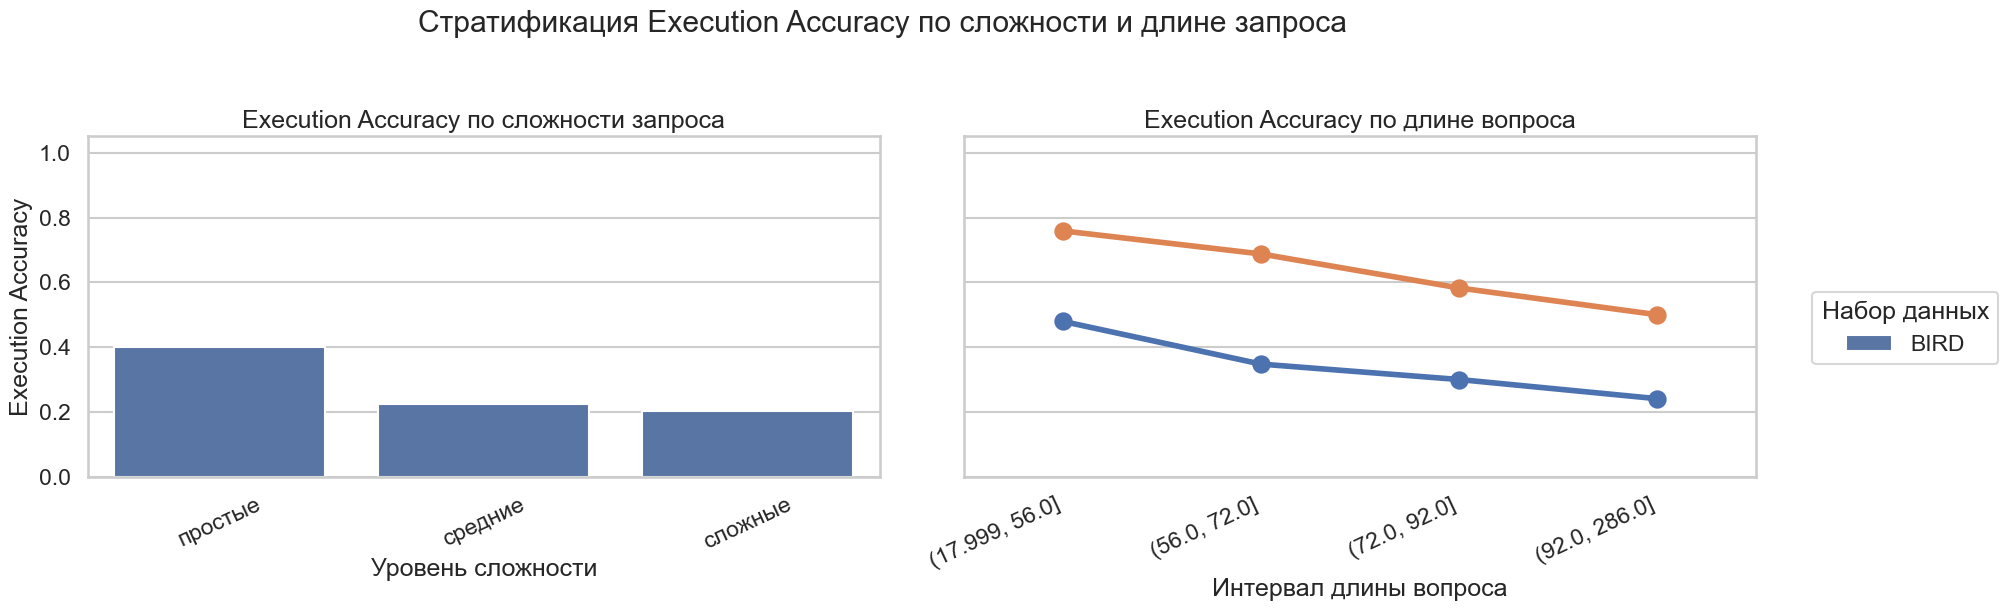

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/final/ea_stratification_ru.png


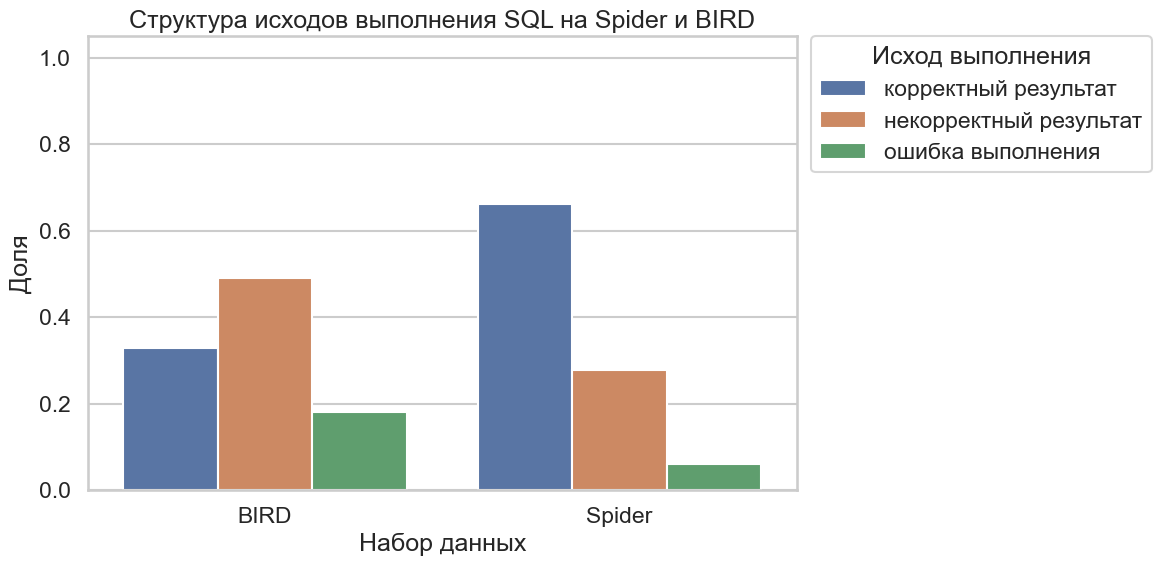

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/final/sql_outcomes_ru.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

difficulty_order = [label for label in ['простые', 'средние', 'сложные'] if label in set(difficulty_df['difficulty_ru'])]
sns.barplot(
    data=difficulty_df,
    x='difficulty_ru',
    y='ea',
    hue='benchmark_ru',
    order=difficulty_order or None,
    ax=axes[0],
)
axes[0].set_title('Execution Accuracy по сложности запроса')
axes[0].set_xlabel('Уровень сложности')
axes[0].set_ylabel('Execution Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)
if axes[0].legend_ is not None:
    axes[0].legend_.remove()

sns.pointplot(
    data=question_len_df,
    x='question_len_bucket_ru',
    y='ea',
    hue='benchmark_ru',
    ax=axes[1],
)
axes[1].set_title('Execution Accuracy по длине вопроса')
axes[1].set_xlabel('Интервал длины вопроса')
axes[1].set_ylabel('Execution Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Набор данных', bbox_to_anchor=(1.01, 0.5), loc='center left')
fig.suptitle('Стратификация Execution Accuracy по сложности и длине запроса', y=1.03)
fig.tight_layout()
ea_stratification_path = FIGURES_DIR / 'ea_stratification_ru.png'
fig.savefig(ea_stratification_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {ea_stratification_path}')

outcome_order = [
    'корректный результат',
    'некорректный результат',
    'ошибка выполнения',
    'пустой SQL',
]
outcome_order = [label for label in outcome_order if label in set(error_mix_df['outcome_ru'])]
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=error_mix_df,
    x='benchmark_ru',
    y='share',
    hue='outcome_ru',
    hue_order=outcome_order or None,
    ax=ax,
)
ax.set_title('Структура исходов выполнения SQL на Spider и BIRD')
ax.set_xlabel('Набор данных')
ax.set_ylabel('Доля')
ax.set_ylim(0, 1.05)
ax.legend(title='Исход выполнения', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
sql_outcomes_path = FIGURES_DIR / 'sql_outcomes_ru.png'
fig.savefig(sql_outcomes_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {sql_outcomes_path}')


Стратификация показывает, что снижение качества на BIRD связано не только с общим усложнением набора, но и с ростом сложности и длины вопроса. Отдельный график исходов уточняет природу ошибок: важно различать техническую исполнимость SQL и семантическую корректность результата. Если запрос выполняется, но возвращает неверный результат, проблема лежит не в синтаксисе, а в выборе таблиц, условий, соединений или агрегаций.


## 8. Интегральная метрика вычислительной эффективности и ее компоненты

В этой работе вычислительная эффективность задается интегральной метрикой `Eff`, которая агрегирует ключевые характеристики вычислительного профиля модели. В текущей версии методики `Eff` рассчитывается на основе времени инференса, числа токенов и стоимости генерации.

Поэтому время инференса, число токенов и стоимость выступают не как конкурирующие метрики того же уровня, а как составляющие `Eff`. В основном тексте сначала показывается сама интегральная метрика, а затем — ее компоненты.


**Таблица 9. Интегральная метрика вычислительной эффективности**

,Модель,Бенчмарк,Интегральная метрика Eff,Нормализованная метрика Eff
2,Arctic-Text2SQL-R1-7B,bird,2212.0469,0.5689
0,ChatGPT 5.2,bird,1018.7061,0.6127
1,DeepSeek V3.2,bird,1363.8088,0.4020
3,Defog-Llama3-SQLCoder-8B q4_0,bird,512.2317,0.1753
4,Hrida-T2SQL q8_0,bird,756.4924,0.3322
7,Arctic-Text2SQL-R1-7B,spider,1676.6640,0.3271
5,ChatGPT 5.2,spider,712.3802,0.2625
6,DeepSeek V3.2,spider,1044.1776,0.1871
8,Defog-Llama3-SQLCoder-8B q4_0,spider,287.3931,0.0025
9,Hrida-T2SQL q8_0,spider,346.2196,0.0715


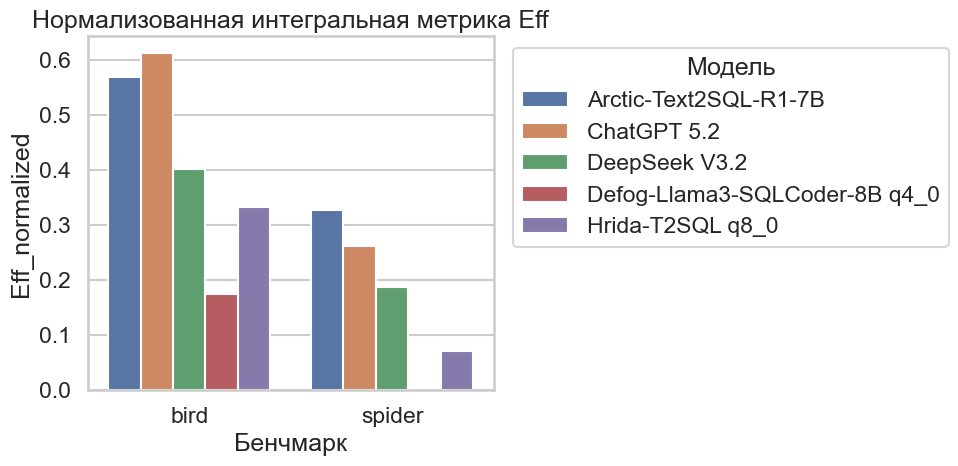

**Таблица 10. Компоненты интегральной метрики `Eff`**

,Модель,Бенчмарк,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
2,Arctic-Text2SQL-R1-7B,bird,6038.1180,1335.3716,0.0000
0,ChatGPT 5.2,bird,2374.4675,1021.2171,0.0019
1,DeepSeek V3.2,bird,3494.5106,1051.5183,0.0003
3,Defog-Llama3-SQLCoder-8B q4_0,bird,733.3158,974.1232,0.0000
4,Hrida-T2SQL q8_0,bird,1081.1594,1440.4817,0.0000
7,Arctic-Text2SQL-R1-7B,spider,4854.2380,734.6422,0.0000
5,ChatGPT 5.2,spider,1895.3430,479.2563,0.0009
6,DeepSeek V3.2,spider,2965.6751,514.9168,0.0002
8,Defog-Llama3-SQLCoder-8B q4_0,spider,531.0612,426.9159,0.0000
9,Hrida-T2SQL q8_0,spider,485.6148,668.4507,0.0000


**Таблица 11. Корреляция компонент интегральной метрики `Eff`**

,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
"Среднее время инференса, мс",1.0000,0.3020,-0.0240
Среднее число токенов,0.3020,1.0000,-0.0360
"Средняя стоимость, USD",-0.0240,-0.0360,1.0000


In [10]:
secondary_cols = ['model_display_name', 'benchmark', 'Eff', 'Eff_normalized', 'Tinf', 'Tok', 'Cost']
secondary_df = cast(Any, main_ea_df[secondary_cols].copy())
secondary_df = secondary_df.sort_values(['benchmark', 'model_display_name'])

eff_view = secondary_df[['model_display_name', 'benchmark', 'Eff', 'Eff_normalized']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Eff': 'Интегральная метрика Eff',
    'Eff_normalized': 'Нормализованная метрика Eff',
})
display(Markdown('**Таблица 9. Интегральная метрика вычислительной эффективности**'))
display(eff_view.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=secondary_df,
    x='benchmark',
    y='Eff_normalized',
    hue='model_display_name',
    ax=ax,
)
ax.set_title('Нормализованная интегральная метрика Eff')
ax.set_xlabel('Бенчмарк')
ax.set_ylabel('Eff_normalized')
ax.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

component_view = secondary_df[['model_display_name', 'benchmark', 'Tinf', 'Tok', 'Cost']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 10. Компоненты интегральной метрики `Eff`**'))
display(component_view.round(4))

secondary_corr = secondary_df[['Tinf', 'Tok', 'Cost']].apply(pd.to_numeric, errors='coerce').corr()
secondary_corr_view = secondary_corr.rename(index={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
}, columns={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 11. Корреляция компонент интегральной метрики `Eff`**'))
display(secondary_corr_view.round(3))


Раздел эффективности стоит читать как отдельное измерение сравнения: он не меняет вывода по качеству, а уточняет, каким вычислительным профилем достигается наблюдаемый `EA`. Метрика `Eff` удобна для компактного сопоставления, а таблица компонент помогает понять, за счет каких факторов складываются различия между моделями.


## 9. Экспертная оценка успешных SQL-запросов

Экспертный слой используется как дополнительная качественная проверка уже успешных `EA`-генераций. В выборку вошли 100 запросов, для которых результат выполнения сгенерированного SQL совпал с результатом эталонного SQL. Два эксперта оценивали не сам факт прохождения `EA`, а полноту, эффективность и читаемость SQL-решения по шкале 1–5.


**Таблица 12. Expert Score на 100 успешных EA-запросах**

,Бенчмарк,Модель,N,Полнота,Эффективность,Читаемость,Expert Score,Эксперт 1,Эксперт 2
0,bird,ChatGPT 5.2,10,4.4500,4.4500,4.5000,4.4670,4.4000,4.5330
1,bird,DeepSeek V3.2,10,4.7000,4.6500,4.7500,4.7000,4.7330,4.6670
2,bird,Arctic-Text2SQL-R1-7B,10,4.8500,4.8500,4.9000,4.8670,4.9000,4.8330
3,bird,Defog-Llama3-SQLCoder-8B q4_0,10,4.9000,4.4000,4.4000,4.5670,4.5330,4.6000
4,bird,Hrida-T2SQL q8_0,10,4.3000,4.6500,4.4500,4.4670,4.4330,4.5000
5,spider,ChatGPT 5.2,10,4.7000,4.8000,4.7000,4.7330,4.7670,4.7000
6,spider,DeepSeek V3.2,10,4.8000,4.7500,4.8000,4.7830,4.8000,4.7670
7,spider,Arctic-Text2SQL-R1-7B,10,4.8000,5.0000,4.8000,4.8670,4.8670,4.8670
8,spider,Defog-Llama3-SQLCoder-8B q4_0,10,4.8000,4.5000,4.4000,4.5670,4.6330,4.5000
9,spider,Hrida-T2SQL q8_0,10,5.0000,4.8500,4.8000,4.8830,4.9000,4.8670


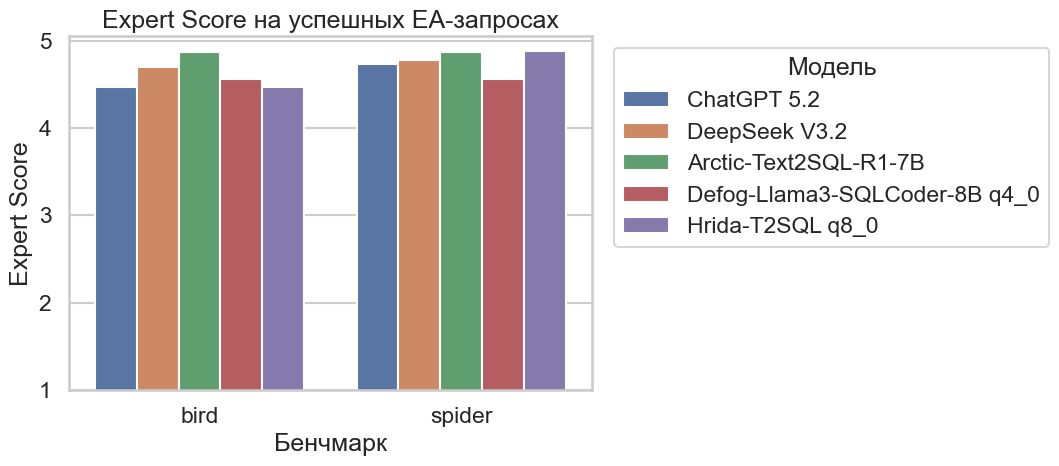

Сохранён файл: `/home/count/code/vkr/results/nl2sql/figures/final/final_expert_score.png`

**Таблица 13. Согласие экспертов**

,Критерий,N,Доля совпадений,Среднее абсолютное расхождение,Cohen's kappa
0,completeness,100,0.9400,0.0600,0.8120
1,efficiency,100,0.8800,0.1200,0.7140
2,readability,100,0.9000,0.1000,0.7800
3,expert_score_rounded,100,0.9100,0.0800,0.7950


In [11]:
expert_by_model_path = RESULTS_DIR / 'metrics' / RUN_LABEL / 'expert_scores_by_model.csv'
expert_agreement_path = RESULTS_DIR / 'metrics' / RUN_LABEL / 'expert_interrater_agreement.csv'
expert_scores_path = RESULTS_DIR / 'metrics' / RUN_LABEL / 'expert_scores.csv'

expert_by_model_df = pd.read_csv(expert_by_model_path) if expert_by_model_path.exists() else pd.DataFrame()
expert_agreement_df = pd.read_csv(expert_agreement_path) if expert_agreement_path.exists() else pd.DataFrame()
expert_scores_df = pd.read_csv(expert_scores_path) if expert_scores_path.exists() else pd.DataFrame()

if expert_by_model_df.empty:
    display(Markdown('Экспертная разметка не найдена.'))
else:
    expert_view = expert_by_model_df.copy()
    expert_view['model_display_name'] = pd.Categorical(
        expert_view['model_display_name'],
        categories=main_ea_df['model_display_name'].drop_duplicates().tolist(),
        ordered=True,
    )
    expert_view = expert_view.sort_values(['benchmark', 'model_display_name'])
    expert_table = expert_view[[
        'benchmark',
        'model_display_name',
        'n',
        'completeness',
        'efficiency',
        'readability',
        'expert_score',
        'expert_1_score',
        'expert_2_score',
    ]].rename(columns={
        'benchmark': 'Бенчмарк',
        'model_display_name': 'Модель',
        'n': 'N',
        'completeness': 'Полнота',
        'efficiency': 'Эффективность',
        'readability': 'Читаемость',
        'expert_score': 'Expert Score',
        'expert_1_score': 'Эксперт 1',
        'expert_2_score': 'Эксперт 2',
    })
    display(Markdown('**Таблица 12. Expert Score на 100 успешных EA-запросах**'))
    display(expert_table.round(3).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=expert_view, x='benchmark', y='expert_score', hue='model_display_name', ax=ax)
    ax.set_title('Expert Score на успешных EA-запросах')
    ax.set_xlabel('Бенчмарк')
    ax.set_ylabel('Expert Score')
    ax.set_ylim(1, 5.05)
    ax.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    expert_fig_path = FIGURES_DIR / 'final_expert_score.png'
    fig.savefig(expert_fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    display(Markdown(f'Сохранён файл: `{expert_fig_path}`'))

if not expert_agreement_df.empty:
    agreement_table = expert_agreement_df.rename(columns={
        'criterion': 'Критерий',
        'n': 'N',
        'exact_agreement': 'Доля совпадений',
        'mean_abs_diff': 'Среднее абсолютное расхождение',
        'cohens_kappa': "Cohen's kappa",
    })
    display(Markdown('**Таблица 13. Согласие экспертов**'))
    display(agreement_table.round(3))


Экспертная проверка дополняет `EA`: она показывает, что даже среди SQL-запросов с совпавшим результатом остаются различия в качестве формулировки решения. Высокие значения Cohen’s kappa указывают на устойчивость разметки между двумя экспертами, а различия по `Expert Score` помогают отделить “работающий” SQL от более аккуратного и поддерживаемого SQL.


## 10. Ограничения исследования

Полученные результаты нужно интерпретировать с учётом нескольких ограничений. Во-первых, основной вывод относится только к сопоставимому набору моделей, включённых в сравнение, и не переносится автоматически на все большие языковые модели или все специализированные Text2SQL-модели. Во-вторых, `EA` остаётся основной метрикой качества, тогда как `Eff` задаёт отдельное измерение вычислительной эффективности. В-третьих, компоненты `Eff` зависят не только от свойств моделей, но и от среды исполнения, поэтому сравнение по эффективности описывает наблюдаемый вычислительный профиль именно в данной экспериментальной постановке.


## 11. Приложение A: Дополнительные результаты `EA`

В приложении приведены дополнительные результаты `EA`, которые расширяют контекст исследования, но не используются для основного сравнительного вывода.


In [12]:
if not appendix_ea_df.empty:
    display(Markdown(
        'Дополнительные результаты `EA`, не входящие в основной сопоставимый корпус из пяти моделей, '
        'не выводятся в активной версии отчёта. Это исключает смешение основного анализа с архивными или вспомогательными прогонами.'
    ))
else:
    display(Markdown('Дополнительные результаты `EA` отсутствуют.'))


Дополнительные результаты `EA`, не входящие в основной сопоставимый корпус из пяти моделей, не выводятся в активной версии отчёта. Это исключает смешение основного анализа с архивными или вспомогательными прогонами.

## 12. Приложение B: Pass@K

`Pass@K` используется как дополнительная характеристика режима многократной генерации. В отличие от `EA`, эта метрика не описывает качество одного выбранного ответа, а оценивает вероятность того, что среди нескольких кандидатов есть хотя бы один корректный SQL-запрос.

Поэтому результаты `pass_k` следует читать внутри собственного режима: они полезны для обсуждения потенциала выбора лучшего кандидата, но не заменяют основные выводы по `EA` и интегральной эффективности `Eff`. Если сопоставимых результатов `pass_k` для некоторого среза нет, этот срез не используется при формулировке итогового вывода.


In [13]:
try:
    pass_k_summary_df = cast(Any, load_summary_metrics(PASS_K_LABEL).copy())
    pass_k_audit_df = cast(Any, build_completeness_audit(PASS_K_LABEL, summary_df=pass_k_summary_df))
    pass_k_main_df = cast(Any, filter_main_report_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
    pass_k_appendix_df = cast(Any, filter_appendix_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
except FileNotFoundError:
    pass_k_audit_df = pd.DataFrame()
    pass_k_main_df = pd.DataFrame()
    pass_k_appendix_df = pd.DataFrame()

if not pass_k_main_df.empty:
    pass_cols = [col for col in ['model_display_name', 'model_family', 'benchmark', 'execution_accuracy', 'pass@1', 'pass@3', 'pass@5', 'pass@1_q05', 'pass@3_q05', 'pass@5_q05', 'pass@1_q95', 'pass@3_q95', 'pass@5_q95'] if col in pass_k_main_df.columns]
    pass_view = pass_k_main_df[pass_cols].sort_values(['benchmark', 'model_family', 'model_display_name']).copy()
    pass_view = pass_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'benchmark': 'Бенчмарк',
        'execution_accuracy': 'EA в режиме pass_k',
        'pass@1': 'Pass@1',
        'pass@3': 'Pass@3',
        'pass@5': 'Pass@5',
        'pass@1_q05': 'Pass@1 q05',
        'pass@3_q05': 'Pass@3 q05',
        'pass@5_q05': 'Pass@5 q05',
        'pass@1_q95': 'Pass@1 q95',
        'pass@3_q95': 'Pass@3 q95',
        'pass@5_q95': 'Pass@5 q95',
    })
    display(Markdown('**Таблица 15. Результаты в режиме многократной генерации**'))
    display(pass_view.round(4))

    pass_k_best_overall = (
        pass_k_main_df.sort_values(['benchmark', 'pass@5'], ascending=[True, False])
        .groupby('benchmark', as_index=False)
        .first()[['benchmark', 'model_display_name', 'model_family', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_display_name': 'Лучшая модель',
            'model_family': 'Класс модели',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 16. Глобально лучшие результаты в режиме многократной генерации**'))
    display(pass_k_best_overall.round(4))

    pass_k_best_by_family = (
        pass_k_main_df.sort_values(['benchmark', 'model_family', 'pass@5'], ascending=[True, True, False])
        .groupby(['benchmark', 'model_family'], as_index=False)
        .first()[['benchmark', 'model_family', 'model_display_name', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_family': 'Класс модели',
            'model_display_name': 'Лучшая модель в классе',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 17. Лучшие результаты классов `M1` и `M2` в режиме многократной генерации**'))
    display(pass_k_best_by_family.round(4))
else:
    display(Markdown('Сопоставимые результаты `pass_k` отсутствуют.'))


**Таблица 15. Результаты в режиме многократной генерации**

,Модель,Класс модели,Бенчмарк,EA в режиме pass_k,Pass@1,Pass@3,Pass@5,Pass@1 q05,Pass@3 q05,Pass@5 q05,Pass@1 q95,Pass@3 q95,Pass@5 q95
0,ChatGPT 5.2,m1,bird,0.2868,0.2875,0.3524,0.3735,0.2690,0.3339,0.3533,0.3044,0.3724,0.3937
1,DeepSeek V3.2,m1,bird,0.3175,0.3201,0.3482,0.3611,0.3009,0.3288,0.3422,0.3407,0.3675,0.3807
2,Arctic-Text2SQL-R1-7B,m2,bird,0.2132,0.2116,0.2253,0.2347,0.1949,0.2070,0.2158,0.2288,0.2425,0.2529
3,Defog-Llama3-SQLCoder-8B q4_0,m2,bird,0.1258,0.1279,0.1456,0.1571,0.1147,0.1317,0.1427,0.1403,0.1596,0.1721
4,Hrida-T2SQL q8_0,m2,bird,0.0378,0.0342,0.0375,0.0404,0.0274,0.0297,0.0326,0.0421,0.0455,0.0489
5,ChatGPT 5.2,m1,spider,0.7418,0.7424,0.7637,0.7718,0.7211,0.7423,0.7505,0.7640,0.7856,0.7921
6,DeepSeek V3.2,m1,spider,0.7379,0.7395,0.7619,0.7698,0.7170,0.7396,0.7476,0.7603,0.7841,0.7892
7,Arctic-Text2SQL-R1-7B,m2,spider,0.5522,0.5538,0.5750,0.5890,0.5308,0.5511,0.5638,0.5793,0.6012,0.6132
8,Defog-Llama3-SQLCoder-8B q4_0,m2,spider,0.4323,0.4300,0.4683,0.4942,0.4068,0.4435,0.4681,0.4549,0.4932,0.5184
9,Hrida-T2SQL q8_0,m2,spider,0.3414,0.3468,0.3656,0.3772,0.3236,0.3406,0.3530,0.3724,0.3894,0.3994


**Таблица 16. Глобально лучшие результаты в режиме многократной генерации**

,Бенчмарк,Лучшая модель,Класс модели,Pass@1,Pass@3,Pass@5
0,bird,ChatGPT 5.2,m1,0.2875,0.3524,0.3735
1,spider,ChatGPT 5.2,m1,0.7424,0.7637,0.7718


**Таблица 17. Лучшие результаты классов `M1` и `M2` в режиме многократной генерации**

,Бенчмарк,Класс модели,Лучшая модель в классе,Pass@1,Pass@3,Pass@5
0,bird,m1,ChatGPT 5.2,0.2875,0.3524,0.3735
1,bird,m2,Arctic-Text2SQL-R1-7B,0.2116,0.2253,0.2347
2,spider,m1,ChatGPT 5.2,0.7424,0.7637,0.7718
3,spider,m2,Arctic-Text2SQL-R1-7B,0.5538,0.5750,0.5890


## 13. Приложение C: Результаты локального синтетического бенчмарка

В приложении приведены результаты дополнительного локального сценария `synthetic_ecommerce`, подготовленного как авторский набор для ограниченного e-commerce-домена. Этот сценарий не используется для основного сравнительного вывода по Spider и BIRD, однако позволяет дополнительно рассмотреть поведение моделей в контролируемом SQLite-окружении с фиксированной схемой, детерминированным заполнением базы и процедурой оценки на основе выполнения SQL.

Локальный синтетический набор не предназначен для прямого сравнения абсолютных значений `EA` со Spider и BIRD. Его назначение состоит в проверке поведения моделей на фиксированной схеме, воспроизводимых данных и управляемых уровнях сложности. Поэтому результаты приложения следует интерпретировать как дополнительный аналитический срез, а не как альтернативу основным внешним наборам данных.


In [14]:
import json

SYNTH_RESULTS_ROOT = Path('results') / 'nl2sql' / 'synthetic_benchmark'
SYNTH_PASSK_ROOT = SYNTH_RESULTS_ROOT / 'pass_k'
SYNTH_FIGURES_DIR = FIGURES_DIR / 'synthetic_appendix'
SYNTH_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SYNTH_MODEL_META = {
    'm1_deepseek': {'display_name': 'DeepSeek', 'model_family': 'm1'},
    'm1_chatgpt': {'display_name': 'ChatGPT', 'model_family': 'm1'},
    'm2_defog': {'display_name': 'Defog-Llama3-SQLCoder-8B', 'model_family': 'm2'},
    'm2_hrida': {'display_name': 'Hrida-T2SQL', 'model_family': 'm2'},
    'm2_arctic': {'display_name': 'Arctic-Text2SQL-R1-7B', 'model_family': 'm2'},
}


def _load_json(path: Path):
    with path.open('r', encoding='utf-8') as fh:
        return json.load(fh)


def _iter_model_dirs(root: Path, mode: str):
    if not root.exists():
        return []
    if mode == 'ea':
        return sorted([p for p in root.iterdir() if p.is_dir() and p.name not in {'pass_k', 'smoke', 'figures'}])
    return sorted([p for p in root.iterdir() if p.is_dir()])


def _load_synthetic_summary(root: Path, mode: str):
    rows = []
    difficulty_rows = []
    for result_dir in _iter_model_dirs(root, mode):
        results_path = result_dir / 'results.json'
        if not results_path.exists():
            continue
        payload = _load_json(results_path)
        meta = SYNTH_MODEL_META.get(result_dir.name, {'display_name': result_dir.name, 'model_family': 'other'})
        row = {
            'model_key': result_dir.name,
            'model_display_name': meta['display_name'],
            'model_family': meta['model_family'],
            'mode': mode,
            **payload['overall'],
        }
        rows.append(row)
        for difficulty, metrics in payload.get('by_difficulty', {}).items():
            difficulty_rows.append({
                'model_key': result_dir.name,
                'model_display_name': meta['display_name'],
                'model_family': meta['model_family'],
                'mode': mode,
                'difficulty': difficulty,
                **metrics,
            })
    return pd.DataFrame(rows), pd.DataFrame(difficulty_rows)


synthetic_ea_df, synthetic_ea_difficulty_df = _load_synthetic_summary(SYNTH_RESULTS_ROOT, mode='ea')
synthetic_passk_df, synthetic_passk_difficulty_df = _load_synthetic_summary(SYNTH_PASSK_ROOT, mode='pass_k')
synthetic_pass_cols = sorted(
    [col for col in synthetic_passk_df.columns if col.startswith('pass@') and '_ci_' not in col and '_q' not in col],
    key=lambda col: int(col.split('@', 1)[1]),
) if not synthetic_passk_df.empty else []

synthetic_spec_df = pd.DataFrame([
    {'Характеристика': 'Предметная область', 'Значение': 'e-commerce analytics'},
    {'Характеристика': 'Схема базы данных', 'Значение': '6 таблиц'},
    {'Характеристика': 'Основное ядро SQL', 'Значение': '30 запросов'},
    {'Характеристика': 'Распределение по сложности', 'Значение': '10 easy / 10 medium / 10 hard'},
    {'Характеристика': 'Дополнительные edge-case сценарии', 'Значение': '8 запросов'},
    {'Характеристика': 'Исполняемая база данных', 'Значение': 'фиксированный snapshot SQLite'},
    {'Характеристика': 'Основные метрики', 'Значение': 'EA, Valid SQL Rate, Pass@K'},
])

display(Markdown('**Таблица 18. Краткая спецификация локального синтетического бенчмарка**'))
display(synthetic_spec_df)
display(Markdown(f'**Источник результатов локального синтетического бенчмарка:** `{SYNTH_RESULTS_ROOT}`'))
display(Markdown(f'Доступно моделей в режиме `EA`: {len(synthetic_ea_df)}; в режиме `pass_k`: {len(synthetic_passk_df)}.'))


**Таблица 18. Краткая спецификация локального синтетического бенчмарка**

,Характеристика,Значение
0,Предметная область,e-commerce analytics
1,Схема базы данных,6 таблиц
2,Основное ядро SQL,30 запросов
3,Распределение по сложности,10 easy / 10 medium / 10 hard
4,Дополнительные edge-case сценарии,8 запросов
5,Исполняемая база данных,фиксированный snapshot SQLite
6,Основные метрики,"EA, Valid SQL Rate, Pass@K"


**Источник результатов локального синтетического бенчмарка:** `results/nl2sql/synthetic_benchmark`

Доступно моделей в режиме `EA`: 5; в режиме `pass_k`: 5.

Сначала рассматриваются результаты режима одного ответа `EA`, поскольку именно этот режим соответствует основной логике сравнения качества первого выбранного SQL-запроса. Затем отдельно анализируется режим `pass_k`, который показывает, насколько несколько независимых генераций повышают шанс получить корректный SQL.

Для синтетического набора важно не смешивать эти метрики в одной категориальной диаграмме. `EA` задаёт базовую точку качества одного ответа, кривая `Pass@K` показывает изменение качества при росте числа попыток, а прирост `Pass@5 - EA` отдельно фиксирует абсолютный эффект многократной генерации.


**Таблица 19. Результаты локального синтетического бенчмарка в режиме `EA`**

,Модель,Класс модели,EA,Доля исполнимых SQL,EA (простые),EA (средние),EA (сложные)
1,DeepSeek,m1,0.8333,1.0000,1.0000,0.8000,0.7000
0,ChatGPT,m1,0.7000,0.8333,0.8000,0.7000,0.6000
2,Arctic-Text2SQL-R1-7B,m2,0.7333,1.0000,1.0000,0.7000,0.5000
4,Hrida-T2SQL,m2,0.7333,1.0000,1.0000,0.8000,0.4000
3,Defog-Llama3-SQLCoder-8B,m2,0.6333,0.9000,1.0000,0.7000,0.2000


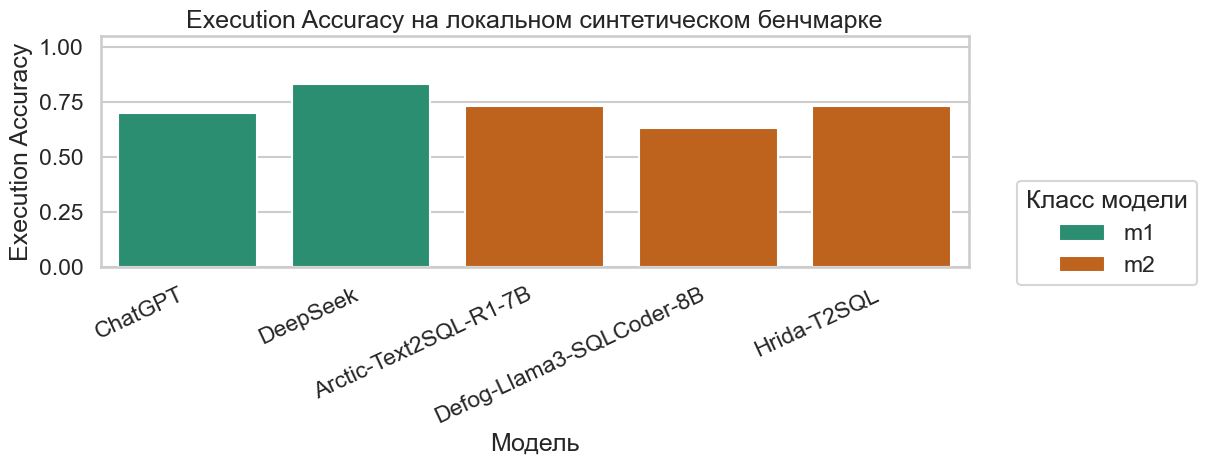

Сохранён рисунок приложения C по EA: /home/count/code/vkr/results/nl2sql/figures/final/synthetic_appendix/synthetic_appendix_ea_ru.png


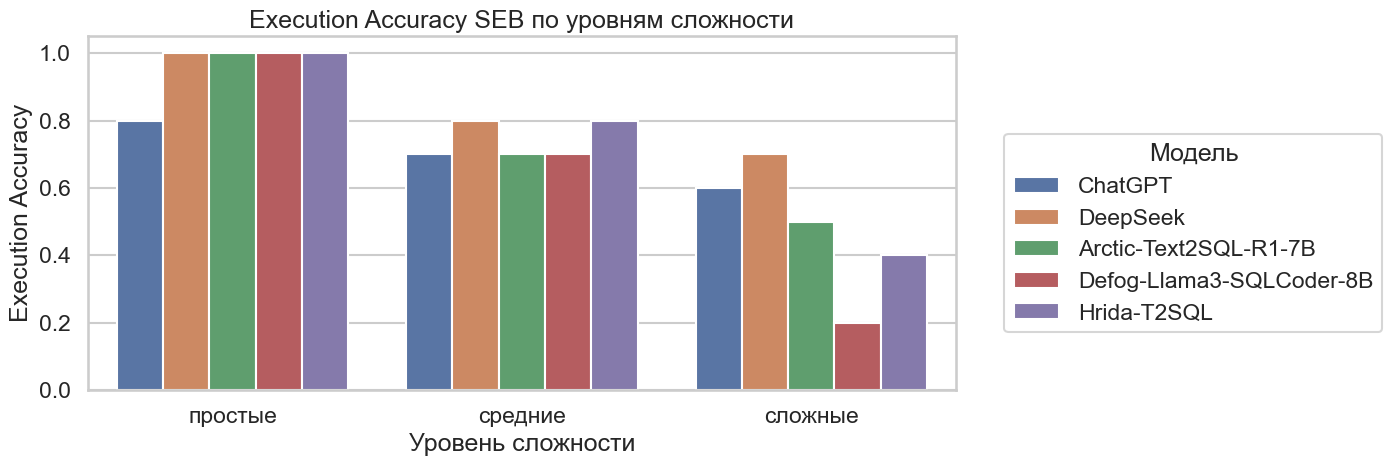

Сохранён рисунок приложения C по EA по сложности: /home/count/code/vkr/results/nl2sql/figures/final/synthetic_appendix/synthetic_appendix_ea_by_difficulty_ru.png


**Таблица 20. Результаты локального синтетического бенчмарка в режиме `pass_k`**

,Модель,Класс модели,EA в режиме pass_k,Доля исполнимых SQL,pass@1,pass@3,pass@5
1,DeepSeek,m1,0.8333,1.0000,0.8133,0.8333,0.8333
0,ChatGPT,m1,0.7000,0.8333,0.7133,0.7333,0.7333
2,Arctic-Text2SQL-R1-7B,m2,0.7667,0.9667,0.7733,0.8200,0.8333
4,Hrida-T2SQL,m2,0.6333,0.8333,0.6133,0.7367,0.7667
3,Defog-Llama3-SQLCoder-8B,m2,0.5333,0.7667,0.5267,0.6600,0.7000


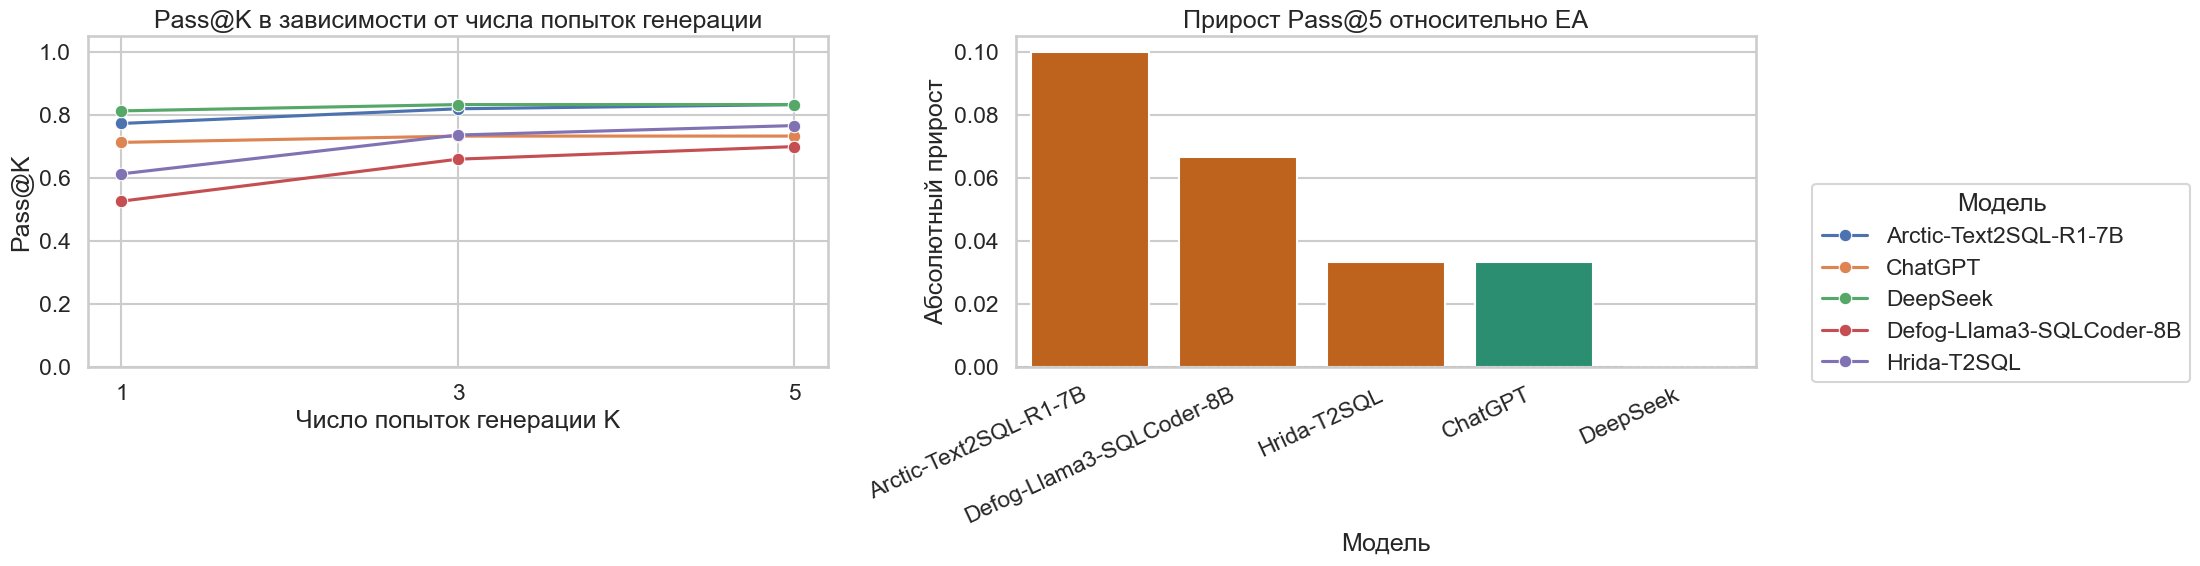

Сохранён рисунок приложения C по Pass@K: /home/count/code/vkr/results/nl2sql/figures/final/synthetic_appendix/seb_passk_and_gain_ru.png


In [15]:
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
METRIC_LABELS = {
    'execution_accuracy': 'Execution Accuracy',
    'valid_sql_rate': 'Доля исполнимых SQL',
    'pass@1': 'Pass@1',
    'pass@3': 'Pass@3',
    'pass@5': 'Pass@5',
}


def _rotate_model_labels(ax):
    ax.tick_params(axis='x', rotation=25)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')


if not synthetic_ea_df.empty:
    synthetic_ea_view = synthetic_ea_df[['model_display_name', 'model_family', 'execution_accuracy', 'valid_sql_rate']].copy()
    ea_difficulty_plot_df = synthetic_ea_difficulty_df.copy()
    ea_difficulty_plot_df['difficulty_ru'] = ea_difficulty_plot_df['difficulty'].map(DIFFICULTY_LABELS).fillna(ea_difficulty_plot_df['difficulty'])
    ea_difficulty_pivot = (
        ea_difficulty_plot_df
        .pivot(index='model_display_name', columns='difficulty_ru', values='execution_accuracy')
        .reindex(columns=['простые', 'средние', 'сложные'])
        .reset_index()
    )
    synthetic_ea_view = synthetic_ea_view.merge(ea_difficulty_pivot, on='model_display_name', how='left')
    synthetic_ea_view = synthetic_ea_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'execution_accuracy': 'EA',
        'valid_sql_rate': 'Доля исполнимых SQL',
        'простые': 'EA (простые)',
        'средние': 'EA (средние)',
        'сложные': 'EA (сложные)',
    })
    display(Markdown('**Таблица 19. Результаты локального синтетического бенчмарка в режиме `EA`**'))
    display(synthetic_ea_view.sort_values(['Класс модели', 'EA'], ascending=[True, False]).round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=synthetic_ea_df, x='model_display_name', y='execution_accuracy', hue='model_family', dodge=False, ax=ax, palette=palette)
    ax.set_title('Execution Accuracy на локальном синтетическом бенчмарке')
    ax.set_xlabel('Модель')
    ax.set_ylabel('Execution Accuracy')
    ax.set_ylim(0, 1.05)
    _rotate_model_labels(ax)
    if ax.legend_ is not None:
        ax.legend_.remove()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Класс модели', bbox_to_anchor=(1.01, 0.5), loc='center left')
    fig.tight_layout()
    ea_figure_path = SYNTH_FIGURES_DIR / 'synthetic_appendix_ea_ru.png'
    fig.savefig(ea_figure_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён рисунок приложения C по EA: {ea_figure_path}')

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=ea_difficulty_plot_df,
        x='difficulty_ru',
        y='execution_accuracy',
        hue='model_display_name',
        order=['простые', 'средние', 'сложные'],
        ax=ax,
    )
    ax.set_title('Execution Accuracy SEB по уровням сложности')
    ax.set_xlabel('Уровень сложности')
    ax.set_ylabel('Execution Accuracy')
    ax.set_ylim(0, 1.05)
    if ax.legend_ is not None:
        ax.legend_.remove()
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Модель', bbox_to_anchor=(1.01, 0.5), loc='center left')
    fig.tight_layout()
    difficulty_figure_path = SYNTH_FIGURES_DIR / 'synthetic_appendix_ea_by_difficulty_ru.png'
    fig.savefig(difficulty_figure_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён рисунок приложения C по EA по сложности: {difficulty_figure_path}')
else:
    display(Markdown('Результаты локального синтетического бенчмарка в режиме `EA` отсутствуют.'))

if not synthetic_passk_df.empty:
    passk_cols = ['model_display_name', 'model_family', 'execution_accuracy', 'valid_sql_rate', *synthetic_pass_cols]
    synthetic_passk_view = synthetic_passk_df[passk_cols].copy().rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'execution_accuracy': 'EA в режиме pass_k',
        'valid_sql_rate': 'Доля исполнимых SQL',
    })
    display(Markdown('**Таблица 20. Результаты локального синтетического бенчмарка в режиме `pass_k`**'))
    display(synthetic_passk_view.sort_values(['Класс модели', synthetic_pass_cols[-1] if synthetic_pass_cols else 'EA в режиме pass_k'], ascending=[True, False]).round(4))

    passk_curve_df = synthetic_passk_df.melt(
        id_vars=['model_key', 'model_display_name', 'model_family'],
        value_vars=synthetic_pass_cols,
        var_name='metric',
        value_name='score',
    ).copy()
    passk_curve_df['metric_ru'] = passk_curve_df['metric'].map(METRIC_LABELS).fillna(passk_curve_df['metric'])
    passk_curve_df['k'] = passk_curve_df['metric'].str.extract(r'pass@(\d+)').astype(int)

    synthetic_gain_df = synthetic_ea_df[['model_key', 'model_display_name', 'model_family', 'execution_accuracy']].merge(
        synthetic_passk_df[['model_key', *synthetic_pass_cols]],
        on='model_key',
        how='inner',
    )
    for metric in synthetic_pass_cols:
        synthetic_gain_df[f'{metric}_gain_vs_ea'] = synthetic_gain_df[metric] - synthetic_gain_df['execution_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.lineplot(
        data=passk_curve_df.sort_values(['model_display_name', 'k']),
        x='k',
        y='score',
        hue='model_display_name',
        marker='o',
        ax=axes[0],
    )
    axes[0].set_title('Pass@K в зависимости от числа попыток генерации')
    axes[0].set_xlabel('Число попыток генерации K')
    axes[0].set_ylabel('Pass@K')
    axes[0].set_xticks(sorted(passk_curve_df['k'].unique()))
    axes[0].set_ylim(0, 1.05)
    if axes[0].legend_ is not None:
        axes[0].legend_.remove()

    final_metric = synthetic_pass_cols[-1] if synthetic_pass_cols else None
    if final_metric:
        gain_col = f'{final_metric}_gain_vs_ea'
        gain_df = synthetic_gain_df[['model_display_name', 'model_family', gain_col]].sort_values(gain_col, ascending=False)
        sns.barplot(data=gain_df, x='model_display_name', y=gain_col, hue='model_family', dodge=False, ax=axes[1], palette=palette)
        axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
        axes[1].set_title(f'Прирост {METRIC_LABELS.get(final_metric, final_metric)} относительно EA')
        axes[1].set_xlabel('Модель')
        axes[1].set_ylabel('Абсолютный прирост')
        axes[1].tick_params(axis='x', rotation=25)
        for label in axes[1].get_xticklabels():
            label.set_horizontalalignment('right')
    else:
        axes[1].axis('off')
        axes[1].text(0.5, 0.5, 'Нет Pass@K-метрик', ha='center', va='center')
    if axes[1].legend_ is not None:
        axes[1].legend_.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Модель', bbox_to_anchor=(1.01, 0.5), loc='center left')
    fig.tight_layout()
    figure_path = SYNTH_FIGURES_DIR / 'seb_passk_and_gain_ru.png'
    fig.savefig(figure_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён рисунок приложения C по Pass@K: {figure_path}')
else:
    display(Markdown('Результаты локального синтетического бенчмарка в режиме `pass_k` отсутствуют.'))


Результаты локального синтетического бенчмарка показывают, что все модели демонстрируют высокое качество на простых запросах, тогда как основные различия проявляются на средних и сложных запросах. Именно в этой части набора становится заметна деградация качества, и именно здесь различия между моделями оказываются наиболее информативными.

В режиме одного ответа на данном локальном наборе наилучшее значение `EA` показала модель DeepSeek. Среди специализированных моделей класса `M2` наиболее сильным кандидатом выступает Arctic-Text2SQL-R1-7B. В режиме `pass_k` интерпретация меняется: важен не только итоговый `Pass@5`, но и то, насколько быстро растёт кривая при увеличении `K`. Если прирост относительно `EA` невелик, несколько попыток почти не компенсируют ошибки первого ответа; если прирост заметен, модель может выиграть от механизма выбора лучшего кандидата.

Дополнительно следует учитывать, что первичные эксперименты с недоопределёнными NL-запросами приводили к резкому снижению `EA` даже при относительно высокой доле исполнимых SQL. После добавления явной привязки вопроса к таблицам, колонкам, `JOIN`, `GROUP BY` и агрегатным операциям значения `EA` существенно выросли. Это подтверждает, что качество формулировки NL-запроса является самостоятельным фактором качества NL2SQL-систем.

Снижение доли исполнимых SQL у ChatGPT в данном сценарии частично связано не с логической ошибкой SQL, а с несовпадением SQL-диалекта и формата ответа: модель возвращала литералы дат в стиле PostgreSQL и JSON-объекты, требующие дополнительной постобработки перед выполнением в SQLite. Поэтому интерпретация результатов ChatGPT в приложении C должна учитывать не только качество генерации SQL, но и форматно-диалектные расхождения между ответом модели и исполняющей средой.

Таким образом, локальный синтетический бенчмарк расширяет аналитический контекст исследования, однако не заменяет внешний корпус Spider/BIRD и не используется как основное основание для вывода о сопоставимости классов `M1` и `M2`.


## 14. Итоговые выводы

В заключительном разделе формулируется итоговая интерпретация результатов исследования применительно к проверяемой гипотезе, различиям между классами моделей и границам применимости полученного вывода.


In [16]:
best_by_family = cast(Any, best_by_family_df.set_index(['benchmark', 'model_family']))
spider_m1 = best_by_family.loc[('spider', 'm1')]
spider_m2 = best_by_family.loc[('spider', 'm2')]
bird_m1 = best_by_family.loc[('bird', 'm1')]
bird_m2 = best_by_family.loc[('bird', 'm2')]

main_pivot = main_ea_df.pivot(index='model_name', columns='benchmark', values='execution_accuracy')
avg_gap = float((main_pivot['spider'] - main_pivot['bird']).mean())
spider_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'spider') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])
bird_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'bird') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])

conclusion_text = f"""
Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` ({spider_m2['model_display_name']}, {spider_m2['execution_accuracy']:.1%}) показывает качество, близкое к лучшему представителю класса `M1` ({spider_m1['model_display_name']}, {spider_m1['execution_accuracy']:.1%}). На `BIRD` лучший представитель класса `M2` ({bird_m2['model_display_name']}, {bird_m2['execution_accuracy']:.1%}) заметно превосходит лучший результат класса `M1` ({bird_m1['model_display_name']}, {bird_m1['execution_accuracy']:.1%}).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на {avg_gap:.1%}, а доля исходов типа `wrong_result` возрастает с {spider_wrong:.1%} на `Spider` до {bird_wrong:.1%} на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.

Экспертная оценка 100 успешных `EA`-запросов дополняет автоматическую проверку: она фиксирует качество SQL-формулировки по полноте, эффективности и читаемости, а не только совпадение результата выполнения. Межэкспертное согласие оказалось высоким: для округленного итогового `Expert Score` Cohen’s kappa составляет 0.795.

Дополнительный вывод состоит в том, что практическая применимость NL2SQL существенно зависит от масштаба и структурной сложности системы. На подготовленном авторском локальном датасете `synthetic_ecommerce` для ограниченного e-commerce-домена качество генерации оказалось высоким: `DeepSeek V3.2` получил `EA = 83.3%` на core-наборе из 30 запросов по схеме из 6 таблиц. Это показывает, что NL2SQL может быть практически применим в ограниченных предметных областях с фиксированной схемой и контролируемым набором типовых запросов. При этом такой результат нельзя переносить на крупные и неоднородные системы: основные бенчмарки подтверждают это ограничение, поскольку при переходе от `Spider` к более сложному `BIRD` качество заметно снижается, а доля `wrong_result` растет. Следовательно, даже большие general-purpose LLM не гарантируют высокую эффективность при усложнении схемы, предметной области и пользовательских запросов.
"""
display(Markdown(conclusion_text))



Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 77.2%) показывает качество, близкое к лучшему представителю класса `M1` (ChatGPT 5.2, 74.3%). На `BIRD` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 53.8%) заметно превосходит лучший результат класса `M1` (ChatGPT 5.2, 36.6%).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на 33.2%, а доля исходов типа `wrong_result` возрастает с 27.9% на `Spider` до 49.0% на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.

Экспертная оценка 100 успешных `EA`-запросов дополняет автоматическую проверку: она фиксирует качество SQL-формулировки по полноте, эффективности и читаемости, а не только совпадение результата выполнения. Межэкспертное согласие оказалось высоким: для округленного итогового `Expert Score` Cohen’s kappa составляет 0.795.

Дополнительный вывод состоит в том, что практическая применимость NL2SQL существенно зависит от масштаба и структурной сложности системы. На подготовленном авторском локальном датасете `synthetic_ecommerce` для ограниченного e-commerce-домена качество генерации оказалось высоким: `DeepSeek V3.2` получил `EA = 83.3%` на core-наборе из 30 запросов по схеме из 6 таблиц. Это показывает, что NL2SQL может быть практически применим в ограниченных предметных областях с фиксированной схемой и контролируемым набором типовых запросов. При этом такой результат нельзя переносить на крупные и неоднородные системы: основные бенчмарки подтверждают это ограничение, поскольку при переходе от `Spider` к более сложному `BIRD` качество заметно снижается, а доля `wrong_result` растет. Следовательно, даже большие general-purpose LLM не гарантируют высокую эффективность при усложнении схемы, предметной области и пользовательских запросов.
